# Stage 00 — Prepare FMI station PM₂.₅ data for the HMA Locomizer analysis

## Purpose

This notebook prepares the historical **FMI / municipal air-quality station observations** downloaded for the Helsinki Metropolitan Area.

> **Terminology note:** these CSVs are station observations, not ENFUSER gridded model output.  
> They are still useful as the historical PM₂.₅ input for the Stage 05 proof of concept.

The notebook:

1. reads every CSV from `paper3/airqualityontario22-25/HMA_pm25/`;
2. validates the FMI station-data schema;
3. combines all files;
4. constructs a local Helsinki timestamp;
5. converts PM₂.₅ to a clean numeric field;
6. removes duplicated station-hours;
7. checks missingness and coverage;
8. creates a regional hourly PM₂.₅ summary across stations;
9. identifies candidate high-PM₂.₅ and lower-PM₂.₅ comparison hours;
10. extracts the current Stage 05 comparison timestamps;
11. saves clean reusable outputs for later notebooks.

The clean output can then be loaded by the Locomizer Stage 05 notebook.


## 1. Imports and project paths

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Project root
# -------------------------------------------------------------------
# This matches the CSC / Roihu structure used in the other notebooks.
PROJECT_ROOT = Path("/scratch/project_2010417")

# Raw FMI station CSV directory supplied for this project
PM25_DIR = (
    PROJECT_ROOT
    / "paper3"
    / "airqualityontario22-25"
    / "HMA_pm25"
)

# Derived outputs are stored separately from the original downloaded CSVs.
DERIVED_DIR = PM25_DIR / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

print("PM2.5 input directory:", PM25_DIR)
print("Derived output directory:", DERIVED_DIR)

if not PM25_DIR.exists():
    raise FileNotFoundError(
        f"{PM25_DIR} does not exist. "
        "Update PROJECT_ROOT or PM25_DIR to match the CSC filesystem."
    )


PM2.5 input directory: /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25
Derived output directory: /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived


## 2. Discover all FMI station CSVs

In [18]:
csv_files = sorted(
    p for p in PM25_DIR.glob("*.csv")
    if p.is_file()
)

print("CSV files found:", len(csv_files))

for p in csv_files:
    print(" -", p.name)

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files were found in {PM25_DIR}"
    )


CSV files found: 11
 - Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 - 19.6.2023_4fbd9c8c-f789-4ea8-bc3d-a43b4399de7f.csv
 - Espoo Luukki_ 17.6.2023 - 19.6.2023_c26d6684-968b-4445-b891-7ed966633768.csv
 - Helsinki Kallio 2_ 17.6.2023 - 19.6.2023_1e801bb4-9afd-4242-8f9a-e75a89c83919.csv
 - Helsinki Mannerheimintie_ 17.6.2023 - 19.6.2023_18613e1b-2bf4-4cc0-86a6-4e72b2949bd3.csv
 - Helsinki Mäkelänkatu_ 17.6.2023 - 19.6.2023_9fa4bc3d-a334-4650-ab16-e281990f691d.csv
 - Helsinki Tapanila_ 17.6.2023 - 19.6.2023_7c4e5ced-f53e-41da-921d-f0b2836c70e1.csv
 - Helsinki Vartiokylä Huivipolku_ 17.6.2023 - 19.6.2023_fe435cf9-8111-4b72-9ebd-ea4b0e3a5045.csv
 - Kauniainen Kauniaistentie_ 17.6.2023 - 19.6.2023_71c635e4-9d06-4746-9271-de7f9d0c658b.csv
 - Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed9f889-0e28-429f-9fe1-f4dff7f71d01.csv
 - Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9ce5517-0fd7-4ac0-b1bc-d5e0379ab1b6.csv
 - Vantaa Tikkurila Neilikkatie_ 17.6.2023 - 19.6.2023_4934ff09-00b8-4e62-a9df-1

## 3. Expected schema

The uploaded FMI files use these columns:

- `Observation station`
- `Year`
- `Month`
- `Day`
- `Time [Local time]`
- `Fine particles <2.5 µm [µg/m3]`
- `Air Quality Index [1/5]`

The notebook validates these before continuing.


In [19]:
STATION_COL = "Observation station"
TIME_COL = "Time [Local time]"
PM25_SOURCE_COL = "Fine particles <2.5 µm [µg/m3]"
AQI_COL = "Air Quality Index [1/5]"

REQUIRED_COLUMNS = {
    STATION_COL,
    "Year",
    "Month",
    "Day",
    TIME_COL,
    PM25_SOURCE_COL,
}

schema_rows = []

for path in csv_files:
    preview = pd.read_csv(path, nrows=5)

    missing = sorted(
        REQUIRED_COLUMNS.difference(preview.columns)
    )

    schema_rows.append({
        "file": path.name,
        "n_columns": len(preview.columns),
        "missing_required_columns": ", ".join(missing),
        "schema_ok": len(missing) == 0,
    })

schema_check = pd.DataFrame(schema_rows)

display(schema_check)

if not schema_check["schema_ok"].all():
    bad = schema_check.loc[
        ~schema_check["schema_ok"],
        ["file", "missing_required_columns"],
    ]
    raise ValueError(
        "At least one CSV does not match the expected FMI schema:\n"
        + bad.to_string(index=False)
    )


,file,n_columns,missing_required_columns,schema_ok
0,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...,7,,True
1,Espoo Luukki_ 17.6.2023 - 19.6.2023_c26d6684-9...,7,,True
2,Helsinki Kallio 2_ 17.6.2023 - 19.6.2023_1e801...,7,,True
3,Helsinki Mannerheimintie_ 17.6.2023 - 19.6.202...,7,,True
4,Helsinki Mäkelänkatu_ 17.6.2023 - 19.6.2023_...,7,,True
5,Helsinki Tapanila_ 17.6.2023 - 19.6.2023_7c4e5...,7,,True
6,Helsinki Vartiokylä Huivipolku_ 17.6.2023 - 1...,7,,True
7,Kauniainen Kauniaistentie_ 17.6.2023 - 19.6.20...,7,,True
8,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed...,7,,True
9,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9c...,7,,True


## 4. Read and combine all station files

In [20]:
frames = []

for path in csv_files:
    df = pd.read_csv(path)

    df["source_file"] = path.name

    frames.append(df)

raw = pd.concat(
    frames,
    ignore_index=True,
)

print("Raw combined rows:", len(raw))
print("Raw stations:", raw[STATION_COL].nunique())

display(raw.head())


Raw combined rows: 528
Raw stations: 10


,Observation station,Year,Month,Day,Time [Local time],Fine particles <2.5 µm [µg/m3],Air Quality Index [1/5],source_file
0,Espoo Leppävaara Läkkisepänkuja,2023,6,17,07:00,17.6,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
1,Espoo Leppävaara Läkkisepänkuja,2023,6,17,08:00,15.3,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
2,Espoo Leppävaara Läkkisepänkuja,2023,6,17,09:00,12.0,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
3,Espoo Leppävaara Läkkisepänkuja,2023,6,17,10:00,10.1,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
4,Espoo Leppävaara Läkkisepänkuja,2023,6,17,11:00,9.8,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...


## 5. Construct local timestamp and clean PM₂.₅

The FMI exports explicitly label the time column as **local time**.

For June 2023 this corresponds to Helsinki summer time (EEST, UTC+3), but the clean table keeps the original local timestamp directly because the Locomizer data are also being compared using local hour-of-day.

A UTC timestamp is also created for reproducibility.


In [21]:
date_part = pd.to_datetime(
    dict(
        year=raw["Year"],
        month=raw["Month"],
        day=raw["Day"],
    ),
    errors="coerce",
)

time_delta = pd.to_timedelta(
    raw[TIME_COL].astype(str) + ":00",
    errors="coerce",
)

raw["datetime_local"] = date_part + time_delta

# Helsinki in June 2023 is EEST (UTC+3).
# localize first, then convert to UTC.
raw["datetime_helsinki"] = (
    raw["datetime_local"]
    .dt.tz_localize(
        "Europe/Helsinki",
        ambiguous="NaT",
        nonexistent="NaT",
    )
)

raw["datetime_utc"] = (
    raw["datetime_helsinki"]
    .dt.tz_convert("UTC")
)

raw["pm25_ugm3"] = pd.to_numeric(
    raw[PM25_SOURCE_COL],
    errors="coerce",
)

if AQI_COL in raw.columns:
    raw["air_quality_index"] = pd.to_numeric(
        raw[AQI_COL],
        errors="coerce",
    )
else:
    raw["air_quality_index"] = np.nan

print("Invalid local timestamps:", raw["datetime_local"].isna().sum())
print("Missing PM2.5 values:", raw["pm25_ugm3"].isna().sum())

display(
    raw[
        [
            STATION_COL,
            "datetime_local",
            "datetime_utc",
            "pm25_ugm3",
            "air_quality_index",
            "source_file",
        ]
    ].head()
)


Invalid local timestamps: 0
Missing PM2.5 values: 0


,Observation station,datetime_local,datetime_utc,pm25_ugm3,air_quality_index,source_file
0,Espoo Leppävaara Läkkisepänkuja,2023-06-17 07:00:00,2023-06-17 04:00:00+00:00,17.6,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
1,Espoo Leppävaara Läkkisepänkuja,2023-06-17 08:00:00,2023-06-17 05:00:00+00:00,15.3,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
2,Espoo Leppävaara Läkkisepänkuja,2023-06-17 09:00:00,2023-06-17 06:00:00+00:00,12.0,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
3,Espoo Leppävaara Läkkisepänkuja,2023-06-17 10:00:00,2023-06-17 07:00:00+00:00,10.1,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
4,Espoo Leppävaara Läkkisepänkuja,2023-06-17 11:00:00,2023-06-17 08:00:00+00:00,9.8,2,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...


## 6. Detect duplicate station-hours

One downloaded station may appear more than once if the same FMI export was saved twice.

Duplicates are identified using:

```text
Observation station + datetime_local
```

If duplicate rows have identical PM₂.₅ values, one copy is retained.

If duplicated station-hours have conflicting PM₂.₅ values, the notebook reports them before aggregation.


In [22]:
duplicate_mask = raw.duplicated(
    subset=[STATION_COL, "datetime_local"],
    keep=False,
)

duplicates = (
    raw.loc[
        duplicate_mask,
        [
            STATION_COL,
            "datetime_local",
            "pm25_ugm3",
            "source_file",
        ],
    ]
    .sort_values(
        [STATION_COL, "datetime_local"]
    )
)

print("Rows involved in duplicated station-hours:", len(duplicates))

if not duplicates.empty:
    display(duplicates.head(30))

conflict_check = (
    raw.loc[duplicate_mask]
    .groupby(
        [STATION_COL, "datetime_local"],
        dropna=False,
    )["pm25_ugm3"]
    .nunique(dropna=False)
    .reset_index(name="n_distinct_pm25")
)

conflicts = conflict_check.loc[
    conflict_check["n_distinct_pm25"] > 1
]

print("Duplicated station-hours with conflicting PM2.5:", len(conflicts))

if not conflicts.empty:
    display(conflicts)


Rows involved in duplicated station-hours: 96


,Observation station,datetime_local,pm25_ugm3,source_file
384,Vantaa Jätevoimala,2023-06-17 07:00:00,14.3,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed...
432,Vantaa Jätevoimala,2023-06-17 07:00:00,14.3,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9c...
385,Vantaa Jätevoimala,2023-06-17 08:00:00,14.3,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed...
433,Vantaa Jätevoimala,2023-06-17 08:00:00,14.3,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9c...
386,Vantaa Jätevoimala,2023-06-17 09:00:00,12.4,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed...
434,Vantaa Jätevoimala,2023-06-17 09:00:00,12.4,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9c...
387,Vantaa Jätevoimala,2023-06-17 10:00:00,14.4,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed...
435,Vantaa Jätevoimala,2023-06-17 10:00:00,14.4,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9c...
388,Vantaa Jätevoimala,2023-06-17 11:00:00,12.0,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_7ed...
436,Vantaa Jätevoimala,2023-06-17 11:00:00,12.0,Vantaa Jätevoimala_ 17.6.2023 - 19.6.2023_c9c...


Duplicated station-hours with conflicting PM2.5: 0


## 7. Build the clean station-hour table

For duplicated downloads, PM₂.₅ is averaged only if multiple values exist for the same station-hour. With exact duplicate exports this simply returns the original value.

The number of source rows contributing to each station-hour is retained as `n_source_rows`.


In [23]:
clean = (
    raw
    .groupby(
        [
            STATION_COL,
            "datetime_local",
            "datetime_helsinki",
            "datetime_utc",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        pm25_ugm3=("pm25_ugm3", "mean"),
        air_quality_index=("air_quality_index", "mean"),
        n_source_rows=("source_file", "size"),
        source_files=(
            "source_file",
            lambda s: " | ".join(sorted(set(s))),
        ),
    )
)

clean = clean.rename(
    columns={STATION_COL: "station"}
)

clean = clean.sort_values(
    ["datetime_local", "station"]
).reset_index(drop=True)

print("Clean station-hour rows:", len(clean))
print("Stations:", clean["station"].nunique())
print(
    "Time range:",
    clean["datetime_local"].min(),
    "to",
    clean["datetime_local"].max(),
)

display(clean.head())


Clean station-hour rows: 480
Stations: 10
Time range: 2023-06-17 07:00:00 to 2023-06-19 06:00:00


,station,datetime_local,datetime_helsinki,datetime_utc,pm25_ugm3,air_quality_index,n_source_rows,source_files
0,Espoo Leppävaara Läkkisepänkuja,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,17.6,2.0,1,Espoo Leppävaara Läkkisepänkuja_ 17.6.2023 ...
1,Espoo Luukki,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,13.5,2.0,1,Espoo Luukki_ 17.6.2023 - 19.6.2023_c26d6684-9...
2,Helsinki Kallio 2,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,12.9,2.0,1,Helsinki Kallio 2_ 17.6.2023 - 19.6.2023_1e801...
3,Helsinki Mannerheimintie,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,21.3,3.0,1,Helsinki Mannerheimintie_ 17.6.2023 - 19.6.202...
4,Helsinki Mäkelänkatu,2023-06-17 07:00:00,2023-06-17 07:00:00+03:00,2023-06-17 04:00:00+00:00,21.4,3.0,1,Helsinki Mäkelänkatu_ 17.6.2023 - 19.6.2023_...


## 8. Station coverage summary

In [24]:
station_summary = (
    clean
    .groupby("station")
    .agg(
        first_observation=("datetime_local", "min"),
        last_observation=("datetime_local", "max"),
        n_hours=("datetime_local", "nunique"),
        n_pm25=("pm25_ugm3", "count"),
        missing_pm25=("pm25_ugm3", lambda s: s.isna().sum()),
        pm25_mean=("pm25_ugm3", "mean"),
        pm25_median=("pm25_ugm3", "median"),
        pm25_max=("pm25_ugm3", "max"),
    )
    .sort_index()
    .reset_index()
)

display(station_summary)


,station,first_observation,last_observation,n_hours,n_pm25,missing_pm25,pm25_mean,pm25_median,pm25_max
0,Espoo Leppävaara Läkkisepänkuja,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,8.260417,8.45,17.6
1,Espoo Luukki,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,8.333333,9.10,13.5
2,Helsinki Kallio 2,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,7.637500,7.65,13.9
3,Helsinki Mannerheimintie,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,10.689583,10.55,21.3
4,Helsinki Mäkelänkatu,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,8.454167,8.40,24.3
5,Helsinki Tapanila,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,8.108333,8.05,17.0
6,Helsinki Vartiokylä Huivipolku,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,7.252083,7.60,16.3
7,Kauniainen Kauniaistentie,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,8.725000,9.25,18.1
8,Vantaa Jätevoimala,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,9.529167,8.65,29.1
9,Vantaa Tikkurila Neilikkatie,2023-06-17 07:00:00,2023-06-19 06:00:00,48,48,0,7.939583,7.85,14.9


## 9. Regional hourly PM₂.₅ summary

Because these are point observations, this does **not** create a gridded pollution surface.

Instead, for every hour it summarizes the network of available HMA stations using:

- mean PM₂.₅;
- median PM₂.₅;
- minimum;
- maximum;
- standard deviation;
- number of stations reporting.

For selecting high- versus lower-pollution comparison periods, the **regional median** is useful because it is less sensitive to a single unusually high roadside station.


In [25]:
regional_hourly = (
    clean
    .groupby(
        "datetime_local",
        as_index=False,
    )
    .agg(
        pm25_mean=("pm25_ugm3", "mean"),
        pm25_median=("pm25_ugm3", "median"),
        pm25_min=("pm25_ugm3", "min"),
        pm25_max=("pm25_ugm3", "max"),
        pm25_std=("pm25_ugm3", "std"),
        n_stations=("pm25_ugm3", "count"),
    )
    .sort_values("datetime_local")
    .reset_index(drop=True)
)

display(regional_hourly.head())


,datetime_local,pm25_mean,pm25_median,pm25_min,pm25_max,pm25_std,n_stations
0,2023-06-17 07:00:00,16.73,16.65,12.9,21.4,2.980324,10
1,2023-06-17 08:00:00,15.28,14.45,13.0,24.3,3.285253,10
2,2023-06-17 09:00:00,12.25,11.90,10.1,16.1,1.882227,10
3,2023-06-17 10:00:00,9.93,9.80,7.3,14.4,2.029806,10
4,2023-06-17 11:00:00,9.57,9.30,7.9,12.1,1.609727,10


## 10. Plot the regional hourly PM₂.₅ series

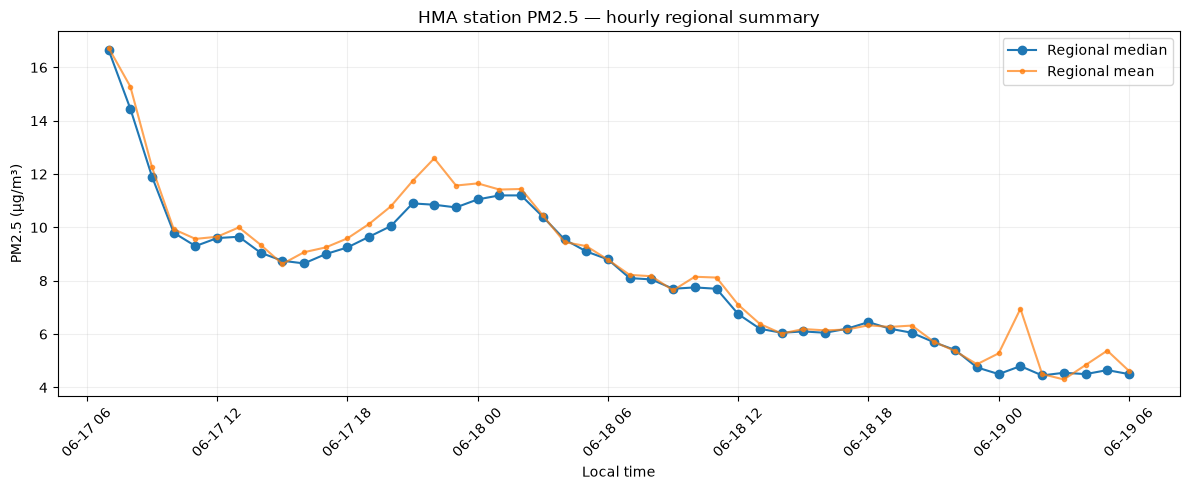

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    regional_hourly["datetime_local"],
    regional_hourly["pm25_median"],
    marker="o",
    label="Regional median",
)

ax.plot(
    regional_hourly["datetime_local"],
    regional_hourly["pm25_mean"],
    marker=".",
    alpha=0.7,
    label="Regional mean",
)

ax.set_xlabel("Local time")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title(
    "HMA station PM2.5 — hourly regional summary"
)

ax.legend()
ax.grid(alpha=0.2)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Find the highest and lowest regional PM₂.₅ hours

This is a **descriptive screening step**, not yet the final causal comparison.

The table helps identify whether the originally selected Locomizer timestamps are environmentally distinct enough to be useful.


In [27]:
highest_hours = (
    regional_hourly
    .sort_values(
        "pm25_median",
        ascending=False,
    )
    .head(10)
)

lowest_hours = (
    regional_hourly
    .sort_values(
        "pm25_median",
        ascending=True,
    )
    .head(10)
)

print("Highest regional-median PM2.5 hours")
display(highest_hours)

print("Lowest regional-median PM2.5 hours")
display(lowest_hours)


Highest regional-median PM2.5 hours


,datetime_local,pm25_mean,pm25_median,pm25_min,pm25_max,pm25_std,n_stations
0,2023-06-17 07:00:00,16.73,16.65,12.9,21.4,2.980324,10
1,2023-06-17 08:00:00,15.28,14.45,13.0,24.3,3.285253,10
2,2023-06-17 09:00:00,12.25,11.90,10.1,16.1,1.882227,10
19,2023-06-18 02:00:00,11.44,11.20,9.0,14.5,1.490861,10
18,2023-06-18 01:00:00,11.42,11.20,10.3,14.7,1.272618,10
17,2023-06-18 00:00:00,11.65,11.05,10.2,15.6,1.658145,10
14,2023-06-17 21:00:00,11.74,10.90,9.6,16.2,2.417621,10
15,2023-06-17 22:00:00,12.59,10.85,9.7,21.9,3.814723,10
16,2023-06-17 23:00:00,11.57,10.75,9.6,16.2,2.043445,10
20,2023-06-18 03:00:00,10.45,10.40,8.2,13.1,1.286900,10


Lowest regional-median PM2.5 hours


,datetime_local,pm25_mean,pm25_median,pm25_min,pm25_max,pm25_std,n_stations
43,2023-06-19 02:00:00,4.50,4.45,3.1,5.4,0.684755,10
47,2023-06-19 06:00:00,4.62,4.50,3.3,6.1,0.840370,10
45,2023-06-19 04:00:00,4.84,4.50,3.9,6.6,0.902096,10
41,2023-06-19 00:00:00,5.28,4.50,4.1,9.7,1.826837,10
44,2023-06-19 03:00:00,4.30,4.55,2.3,5.4,0.855050,10
46,2023-06-19 05:00:00,5.38,4.65,3.8,13.4,2.866589,10
40,2023-06-18 23:00:00,4.87,4.75,4.1,5.7,0.567744,10
42,2023-06-19 01:00:00,6.95,4.80,2.9,29.1,7.821374,10
39,2023-06-18 22:00:00,5.36,5.40,4.4,6.5,0.643256,10
38,2023-06-18 21:00:00,5.72,5.70,4.5,7.4,0.880404,10


## 12. Compare same clock-hour across days

For mobility analysis, comparing different hours of the day can confound pollution change with normal daily activity rhythms.

This cell compares each local hour across the available dates and calculates the range in regional median PM₂.₅.

A useful proof-of-concept pair is often:

- the **same clock hour** on two dates;
- enough stations reporting;
- a clear difference in regional PM₂.₅.


In [28]:
regional_hourly["date"] = (
    regional_hourly["datetime_local"].dt.date
)

regional_hourly["hour"] = (
    regional_hourly["datetime_local"].dt.hour
)

hour_contrast = (
    regional_hourly
    .groupby("hour")
    .agg(
        n_times=("datetime_local", "count"),
        min_pm25=("pm25_median", "min"),
        max_pm25=("pm25_median", "max"),
        pm25_range=("pm25_median", lambda s: s.max() - s.min()),
        min_station_count=("n_stations", "min"),
    )
    .reset_index()
    .sort_values(
        "pm25_range",
        ascending=False,
    )
)

display(hour_contrast)


,hour,n_times,min_pm25,max_pm25,pm25_range,min_station_count
7,7,2,8.10,16.65,8.55,10
2,2,2,4.45,11.20,6.75,10
0,0,2,4.50,11.05,6.55,10
1,1,2,4.80,11.20,6.40,10
8,8,2,8.05,14.45,6.40,10
23,23,2,4.75,10.75,6.00,10
3,3,2,4.55,10.40,5.85,10
22,22,2,5.40,10.85,5.45,10
21,21,2,5.70,10.90,5.20,10
4,4,2,4.50,9.55,5.05,10


## 13. Current Stage 05 timestamps

The current Locomizer Stage 05 notebook uses:

- **Time A:** 2023-06-17 12:00 local
- **Time B:** 2023-06-18 12:00 local

This cell extracts those station observations and shows whether PM₂.₅ rose or fell between them.


In [29]:
TIME_A = pd.Timestamp("2023-06-17 12:00")
TIME_B = pd.Timestamp("2023-06-18 12:00")

two_time_station = clean.loc[
    clean["datetime_local"].isin(
        [TIME_A, TIME_B]
    )
].copy()

two_time_station["time_label"] = np.where(
    two_time_station["datetime_local"] == TIME_A,
    "time_A",
    "time_B",
)

display(
    two_time_station[
        [
            "time_label",
            "station",
            "datetime_local",
            "pm25_ugm3",
        ]
    ].sort_values(
        ["station", "datetime_local"]
    )
)

two_time_regional = regional_hourly.loc[
    regional_hourly["datetime_local"].isin(
        [TIME_A, TIME_B]
    )
].copy()

display(two_time_regional)


,time_label,station,datetime_local,pm25_ugm3
50,time_A,Espoo Leppävaara Läkkisepänkuja,2023-06-17 12:00:00,9.9
290,time_B,Espoo Leppävaara Läkkisepänkuja,2023-06-18 12:00:00,7.2
51,time_A,Espoo Luukki,2023-06-17 12:00:00,10.1
291,time_B,Espoo Luukki,2023-06-18 12:00:00,6.8
52,time_A,Helsinki Kallio 2,2023-06-17 12:00:00,9.7
292,time_B,Helsinki Kallio 2,2023-06-18 12:00:00,7.0
53,time_A,Helsinki Mannerheimintie,2023-06-17 12:00:00,11.5
293,time_B,Helsinki Mannerheimintie,2023-06-18 12:00:00,10.0
54,time_A,Helsinki Mäkelänkatu,2023-06-17 12:00:00,8.9
294,time_B,Helsinki Mäkelänkatu,2023-06-18 12:00:00,6.5


,datetime_local,pm25_mean,pm25_median,pm25_min,pm25_max,pm25_std,n_stations,date,hour
5,2023-06-17 12:00:00,9.65,9.60,8.3,11.5,0.874643,10,2023-06-17,12
29,2023-06-18 12:00:00,7.10,6.75,5.6,10.0,1.498888,10,2023-06-18,12


## 14. Station-by-station change from Time A to Time B

Positive `delta_pm25` means PM₂.₅ increased at Time B.  
Negative `delta_pm25` means PM₂.₅ decreased.


In [30]:
wide = (
    two_time_station
    .pivot_table(
        index="station",
        columns="time_label",
        values="pm25_ugm3",
        aggfunc="mean",
    )
    .reset_index()
)

if {"time_A", "time_B"}.issubset(wide.columns):
    wide["delta_pm25"] = (
        wide["time_B"] - wide["time_A"]
    )

    wide["pct_change_pm25"] = np.where(
        wide["time_A"] != 0,
        100
        * wide["delta_pm25"]
        / wide["time_A"],
        np.nan,
    )

display(wide)


time_label,station,time_A,time_B,delta_pm25,pct_change_pm25
0,Espoo Leppävaara Läkkisepänkuja,9.9,7.2,-2.7,-27.272727
1,Espoo Luukki,10.1,6.8,-3.3,-32.673267
2,Helsinki Kallio 2,9.7,7.0,-2.7,-27.835052
3,Helsinki Mannerheimintie,11.5,10.0,-1.5,-13.043478
4,Helsinki Mäkelänkatu,8.9,6.5,-2.4,-26.966292
5,Helsinki Tapanila,9.5,5.7,-3.8,-40.000000
6,Helsinki Vartiokylä Huivipolku,8.3,5.6,-2.7,-32.530120
7,Kauniainen Kauniaistentie,10.2,9.5,-0.7,-6.862745
8,Vantaa Jätevoimala,9.4,6.0,-3.4,-36.170213
9,Vantaa Tikkurila Neilikkatie,9.0,6.7,-2.3,-25.555556


## 15. Automatically identify strongest same-hour contrast

This selects the pair of observations with the same clock hour that has the largest absolute difference in regional median PM₂.₅.

This is useful for choosing a visually and analytically strong proof-of-concept pair before scaling the analysis to the full Locomizer time series.


In [31]:
candidate_pairs = []

for hour, group in regional_hourly.groupby("hour"):
    group = group.sort_values("datetime_local")

    if len(group) < 2:
        continue

    rows = group.to_dict("records")

    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            a = rows[i]
            b = rows[j]

            candidate_pairs.append({
                "hour": hour,
                "time_A": a["datetime_local"],
                "time_B": b["datetime_local"],
                "pm25_A_median": a["pm25_median"],
                "pm25_B_median": b["pm25_median"],
                "delta_pm25": (
                    b["pm25_median"]
                    - a["pm25_median"]
                ),
                "abs_delta_pm25": abs(
                    b["pm25_median"]
                    - a["pm25_median"]
                ),
                "n_stations_A": a["n_stations"],
                "n_stations_B": b["n_stations"],
            })

candidate_pairs = pd.DataFrame(candidate_pairs)

if not candidate_pairs.empty:
    candidate_pairs = (
        candidate_pairs
        .sort_values(
            "abs_delta_pm25",
            ascending=False,
        )
        .reset_index(drop=True)
    )

display(candidate_pairs.head(20))


,hour,time_A,time_B,pm25_A_median,pm25_B_median,delta_pm25,abs_delta_pm25,n_stations_A,n_stations_B
0,7,2023-06-17 07:00:00,2023-06-18 07:00:00,16.65,8.10,-8.55,8.55,10,10
1,2,2023-06-18 02:00:00,2023-06-19 02:00:00,11.20,4.45,-6.75,6.75,10,10
2,0,2023-06-18 00:00:00,2023-06-19 00:00:00,11.05,4.50,-6.55,6.55,10,10
3,1,2023-06-18 01:00:00,2023-06-19 01:00:00,11.20,4.80,-6.40,6.40,10,10
4,8,2023-06-17 08:00:00,2023-06-18 08:00:00,14.45,8.05,-6.40,6.40,10,10
5,23,2023-06-17 23:00:00,2023-06-18 23:00:00,10.75,4.75,-6.00,6.00,10,10
6,3,2023-06-18 03:00:00,2023-06-19 03:00:00,10.40,4.55,-5.85,5.85,10,10
7,22,2023-06-17 22:00:00,2023-06-18 22:00:00,10.85,5.40,-5.45,5.45,10,10
8,21,2023-06-17 21:00:00,2023-06-18 21:00:00,10.90,5.70,-5.20,5.20,10,10
9,4,2023-06-18 04:00:00,2023-06-19 04:00:00,9.55,4.50,-5.05,5.05,10,10


## 16. Save clean reusable outputs

Outputs:

```text
HMA_pm25/
└── derived/
    ├── hma_pm25_station_hour_clean.csv
    ├── hma_pm25_station_hour_clean.parquet
    ├── hma_pm25_station_summary.csv
    ├── hma_pm25_regional_hourly.csv
    ├── hma_pm25_same_hour_candidate_pairs.csv
    ├── hma_pm25_stage05_two_time_station.csv
    └── hma_pm25_stage05_two_time_regional.csv
```

The Parquet station-hour file is the preferred input for later notebooks.


In [32]:
clean_csv = (
    DERIVED_DIR
    / "hma_pm25_station_hour_clean.csv"
)

clean_parquet = (
    DERIVED_DIR
    / "hma_pm25_station_hour_clean.parquet"
)

station_summary_path = (
    DERIVED_DIR
    / "hma_pm25_station_summary.csv"
)

regional_path = (
    DERIVED_DIR
    / "hma_pm25_regional_hourly.csv"
)

pairs_path = (
    DERIVED_DIR
    / "hma_pm25_same_hour_candidate_pairs.csv"
)

two_station_path = (
    DERIVED_DIR
    / "hma_pm25_stage05_two_time_station.csv"
)

two_regional_path = (
    DERIVED_DIR
    / "hma_pm25_stage05_two_time_regional.csv"
)

clean.to_csv(
    clean_csv,
    index=False,
)

clean.to_parquet(
    clean_parquet,
    index=False,
)

station_summary.to_csv(
    station_summary_path,
    index=False,
)

regional_hourly.to_csv(
    regional_path,
    index=False,
)

candidate_pairs.to_csv(
    pairs_path,
    index=False,
)

two_time_station.to_csv(
    two_station_path,
    index=False,
)

two_time_regional.to_csv(
    two_regional_path,
    index=False,
)

print("Saved:")
for p in [
    clean_csv,
    clean_parquet,
    station_summary_path,
    regional_path,
    pairs_path,
    two_station_path,
    two_regional_path,
]:
    print(" -", p)


Saved:
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_station_hour_clean.csv
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_station_hour_clean.parquet
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_station_summary.csv
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_regional_hourly.csv
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_same_hour_candidate_pairs.csv
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_stage05_two_time_station.csv
 - /scratch/project_2010417/paper3/airqualityontario22-25/HMA_pm25/derived/hma_pm25_stage05_two_time_regional.csv


## 17. Minimal hand-off to Stage 05

Stage 05 can now load the clean station observations with:

```python
from pathlib import Path
import pandas as pd

PM25_CLEAN = Path(
    "/scratch/project_2010417/"
    "paper3/airqualityontario22-25/"
    "HMA_pm25/derived/"
    "hma_pm25_station_hour_clean.parquet"
)

pm25_station = pd.read_parquet(PM25_CLEAN)
```

At this stage, the PM₂.₅ data are still **station points**, not a raster.

Therefore Stage 05 should initially use the regional hourly PM₂.₅ summary to select and characterize comparison periods.

A later spatial step can add station coordinates and construct an explicitly documented interpolation / nearest-station surface if needed. That should be treated separately from true FMI ENFUSER gridded output.
